Download the NIH data on sequencing cost (pdated until 2022)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
seq_cost = pd.read_csv('/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/Sequencing_Cost_Data_Table_May2022.csv')
seq_cost.drop(columns=[' Cost per Genome ','Unnamed: 3'], inplace=True)
seq_cost.dropna(inplace=True)
seq_cost

,Date,Cost per Mb
0,Sep-01,"$5,292.39"
1,Mar-02,"$3,898.64"
2,Sep-02,"$3,413.80"
3,Mar-03,"$2,986.20"
4,Oct-03,"$2,230.98"
...,...,...
73,May-21,$0.005
74,Aug-21,$0.006
75,Nov-21,$0.006
76,Feb-22,$0.006


In [32]:
seq_cost.rename(columns={' Cost per Mb ': 'Cost_per_Mb'}, inplace=True)

In [33]:
# Clean the cost data for plotting
# Remove dollar signs and commas, then convert to numeric
seq_cost['Cost_per_Mb_numeric'] = seq_cost['Cost_per_Mb'].str.replace('$', '').str.replace(',', '').astype(float)

# Display the cleaned data
print("First few rows of cleaned data:")
print(seq_cost[['Date', 'Cost_per_Mb', 'Cost_per_Mb_numeric']].head())
print("\nLast few rows of cleaned data:")
print(seq_cost[['Date', 'Cost_per_Mb', 'Cost_per_Mb_numeric']].tail())

# Check the range of values for log plotting
print(f"\nCost per Mb range: ${seq_cost['Cost_per_Mb_numeric'].min():.3f} to ${seq_cost['Cost_per_Mb_numeric'].max():.2f}")
print(f"Log10 range: {np.log10(seq_cost['Cost_per_Mb_numeric'].min()):.2f} to {np.log10(seq_cost['Cost_per_Mb_numeric'].max()):.2f}")

First few rows of cleaned data:
     Date Cost_per_Mb  Cost_per_Mb_numeric
0  Sep-01   $5,292.39              5292.39
1  Mar-02   $3,898.64              3898.64
2  Sep-02   $3,413.80              3413.80
3  Mar-03   $2,986.20              2986.20
4  Oct-03   $2,230.98              2230.98

Last few rows of cleaned data:
      Date Cost_per_Mb  Cost_per_Mb_numeric
73  May-21      $0.005                0.005
74  Aug-21      $0.006                0.006
75  Nov-21      $0.006                0.006
76  Feb-22      $0.006                0.006
77  May-22      $0.006                0.006

Cost per Mb range: $0.005 to $5292.39
Log10 range: -2.30 to 3.72


In [34]:
# Check column names
print("Column names:", seq_cost.columns.tolist())
print("\nFirst few rows of original data:")
print(seq_cost.head())

Column names: ['Date', 'Cost_per_Mb', 'Cost_per_Mb_numeric']

First few rows of original data:
     Date Cost_per_Mb  Cost_per_Mb_numeric
0  Sep-01   $5,292.39              5292.39
1  Mar-02   $3,898.64              3898.64
2  Sep-02   $3,413.80              3413.80
3  Mar-03   $2,986.20              2986.20
4  Oct-03   $2,230.98              2230.98


In [35]:
# Extract year from date for plotting
seq_cost['Year'] = seq_cost['Date'].str.extract(r'(\d{2})$').astype(int) + 2000
seq_cost.loc[seq_cost['Year'] > 2030, 'Year'] -= 100  # Handle dates like "01" = 2001, not 2101

# Convert dates to proper datetime for time-proportional spacing
date_mapping = {
    'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04',
    'May': '05', 'Jun': '06', 'Jul': '07', 'Aug': '08', 
    'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
}

# Create proper datetime
seq_cost['Month'] = seq_cost['Date'].str.extract(r'([A-Za-z]+)').replace(date_mapping)
seq_cost['DateTime'] = pd.to_datetime(seq_cost['Year'].astype(str) + '-' + seq_cost['Month'] + '-01')

print("Data processing complete:")
print(seq_cost[['Date', 'Year', 'DateTime', 'Cost_per_Mb_numeric']].head())

Data processing complete:
     Date  Year   DateTime  Cost_per_Mb_numeric
0  Sep-01  2001 2001-09-01              5292.39
1  Mar-02  2002 2002-03-01              3898.64
2  Sep-02  2002 2002-09-01              3413.80
3  Mar-03  2003 2003-03-01              2986.20
4  Oct-03  2003 2003-10-01              2230.98


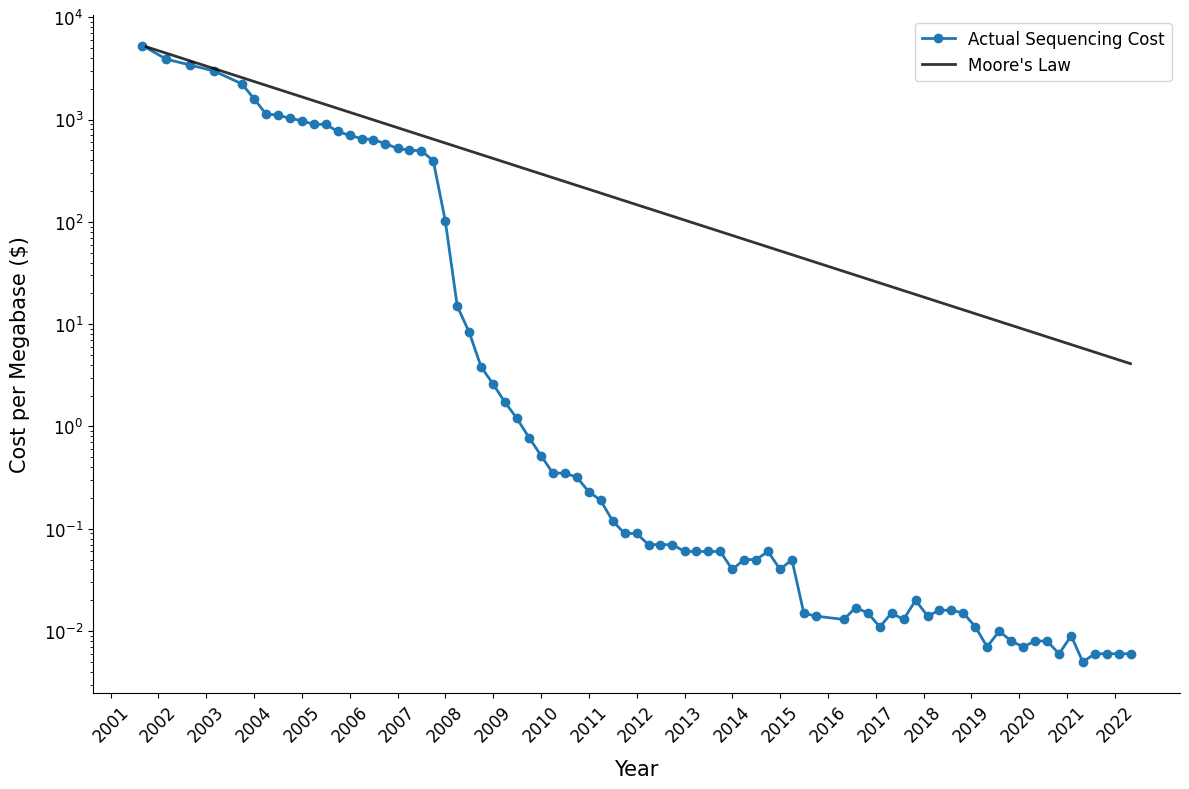

Starting point: 2001-09 at $5,292.39
If Moore's Law applied, cost in 2022-05 would be: $4.111864
Actual cost in 2022-05: $0.006000


In [36]:
# Create plot with Moore's Law comparison
fig, ax = plt.subplots(figsize=(12,8))

# Plot the actual sequencing cost data
ax.plot(seq_cost['DateTime'], seq_cost['Cost_per_Mb_numeric'], marker='o', linewidth=2, markersize=6, 
        label='Actual Sequencing Cost', color='#1f77b4')

# Create Moore's Law reference line
# Moore's Law: cost halves every 2 years (or every 24 months)
start_date = seq_cost['DateTime'].iloc[0]
start_cost = seq_cost['Cost_per_Mb_numeric'].iloc[0]
end_date = seq_cost['DateTime'].iloc[-1]

# Create a time range for Moore's Law projection
moores_dates = pd.date_range(start=start_date, end=end_date, freq='M')

# Calculate years elapsed from start
years_elapsed = (moores_dates - start_date).days / 365.25

# Moore's Law: cost = start_cost * (0.5)^(years_elapsed/2)
# This means cost halves every 2 years
moores_costs = start_cost * (0.5) ** (years_elapsed / 2)

# Plot Moore's Law line
ax.plot(moores_dates, moores_costs, '-', linewidth=2, color='black', alpha=0.8,
        label="Moore's Law")

ax.set_yscale('log')

# Set up x-axis to show only years
years = sorted(seq_cost['Year'].unique())
year_positions = [pd.Timestamp(f'{year}-01-01') for year in years]

ax.set_xticks(year_positions)
ax.set_xticklabels([str(year) for year in years], rotation=45, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_xlabel('Year', fontsize=15, labelpad=10)
ax.set_ylabel('Cost per Megabase ($)', fontsize=15, labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig('/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/figures/Intro/sequencing_cost_vs_moores_law.svg', 
            format='svg', dpi=1200, bbox_inches='tight')

print(f"Starting point: {start_date.strftime('%Y-%m')} at ${start_cost:,.2f}")
print(f"If Moore's Law applied, cost in {end_date.strftime('%Y-%m')} would be: ${moores_costs[-1]:.6f}")
print(f"Actual cost in {end_date.strftime('%Y-%m')}: ${seq_cost['Cost_per_Mb_numeric'].iloc[-1]:.6f}")